# XGBoost Final Viva Ready (Colab-Friendly)

Full structured notebook for classification with `Diabetes` as target. Includes hyperparameter tuning, evaluation, and feature importance.

Designed for iPhone/Colab use.

In [11]:
import os, inspect, numpy as np, pandas as pd, torch, matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report, confusion_matrix

# --- Google Colab file upload (iPhone-friendly) ---
 # Tap 'Choose Files' to upload your CSV

# Automatically pick the uploaded file
DATA_PATH = '/content/pipline3.csv'
TARGET_COLUMN = 'Diabetes'  # preset target column
df = pd.read_csv(DATA_PATH)
OUTPUT_DIR = '/content/xgb_viva_output'
RANDOM_STATE = 42

import os
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"DATA_PATH set to {DATA_PATH}, TARGET_COLUMN = {TARGET_COLUMN}, OUTPUT_DIR = {OUTPUT_DIR}")


DATA_PATH set to /content/pipline3.csv, TARGET_COLUMN = Diabetes, OUTPUT_DIR = /content/xgb_viva_output


In [12]:
import re, difflib

# 1) Normalize column names: strip spaces, collapse whitespace, remove weird chars, lower-case
def normalize_col(s: str) -> str:
    s = s.strip()
    s = re.sub(r"\s+", " ", s)          # collapse internal whitespace
    s = s.replace(" ", "_")             # spaces -> underscores
    s = re.sub(r"[^\w_]", "", s)        # drop non-alnum/underscore
    return s.lower()

orig_cols = list(df.columns)
df.columns = [normalize_col(c) for c in df.columns]

# 2) Try to identify the target column robustly
CANDIDATES = [
    "diabetes", "is_diabetic", "diabetic", "outcome", "class", "label", "target", "y"
]

target_col = None
for c in CANDIDATES:
    if c in df.columns:
        target_col = c
        break

# If not found, try fuzzy match
if target_col is None:
    match = difflib.get_close_matches("diabetes", df.columns, n=1, cutoff=0.7)
    if match:
        target_col = match[0]

# 3) If still not found, raise a clear error with suggestions
if target_col is None:
    raise KeyError(
        "Could not find a target column. Looked for names like: "
        f"{CANDIDATES}. Found columns: {df.columns.tolist()}. "
        "Tip: rename your label column to 'target' or include it in CANDIDATES."
    )

print(f"Using target column: {target_col}")

# 4) Separate features/target
y = df[target_col]
X = df.drop(columns=[target_col])

# 5) Identify numeric & categorical columns
num_cols = X.select_dtypes(include=["number", "float64", "int64", "float32", "int32"]).columns.tolist()
cat_cols = [c for c in X.columns if c not in num_cols]

print(f"Numeric features: {num_cols}")
print(f"Categorical features: {cat_cols}")

# 6) Preprocess + model
numeric_tf = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler(with_mean=False) if len(num_cols) > 0 else "passthrough")
])

categorical_tf = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=True))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_tf, num_cols),
        ("cat", categorical_tf, cat_cols),
    ],
    remainder="drop"
)

model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.06,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    eval_metric="logloss"
)

pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("clf", model)
])

# 7) Train/validate
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

pipe.fit(X_train, y_train)

y_pred = pipe.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.4f}")
print("\nClassification report:\n", classification_report(y_test, y_pred))
print("\nConfusion matrix:\n", confusion_matrix(y_test, y_pred))

# (Optional) Save model
joblib.dump(pipe, "xgb_diabetes_pipeline.joblib")
print("Saved: xgb_diabetes_pipeline.joblib")


Using target column: diabetes
Numeric features: ['unnamed_0', 'age', 'hypertension', 'heart_disease', 'bmi', 'hba1c_level', 'blood_glucose_level', 'bmi_category', 'age_group', 'htn_heart_interaction', 'gender_female', 'gender_male', 'gender_other', 'smoking_history_no_info', 'smoking_history_current', 'smoking_history_ever', 'smoking_history_former', 'smoking_history_never', 'smoking_history_not_current']
Categorical features: []
Accuracy: 0.9072

Classification report:
               precision    recall  f1-score   support

           0       0.92      0.90      0.91      1697
           1       0.90      0.92      0.91      1696

    accuracy                           0.91      3393
   macro avg       0.91      0.91      0.91      3393
weighted avg       0.91      0.91      0.91      3393


Confusion matrix:
 [[1522  175]
 [ 140 1556]]
Saved: xgb_diabetes_pipeline.joblib


In [13]:
import re, difflib

# --- 0) Load ---
df = pd.read_csv(DATA_PATH)
print("Raw columns:", list(df.columns))
print('Dataset shape:', df.shape)

# --- 1) Normalize column names (safe + reversible map) ---
def normalize_col(s: str) -> str:
    s = s.strip()
    s = re.sub(r"\s+", " ", s)          # collapse internal whitespace
    s = s.replace(" ", "_")             # spaces -> underscores
    s = re.sub(r"[^\w_]", "", s)        # drop non-alnum/underscore
    return s.lower()

orig_cols = list(df.columns)
norm_cols = [normalize_col(c) for c in orig_cols]
colmap = dict(zip(orig_cols, norm_cols))
df.columns = norm_cols
print("Normalized columns:", list(df.columns))

# --- 2) Pick TARGET column robustly ---
# If you already have a preferred variable, put it here (normalized form):
PREFERRED_TARGET = None  # e.g., "diabetes" or "outcome"

CANDIDATES = [
    "diabetes","is_diabetic","diabetic","outcome","class",
    "label","target","y","status"
]

target_col = None

# preferred
if PREFERRED_TARGET and PREFERRED_TARGET in df.columns:
    target_col = PREFERRED_TARGET

# direct candidates
if target_col is None:
    for c in CANDIDATES:
        if c in df.columns:
            target_col = c
            break

# fuzzy match for "diabetes" if still not found
if target_col is None:
    match = difflib.get_close_matches("diabetes", df.columns, n=1, cutoff=0.7)
    if match:
        target_col = match[0]

# final check
if target_col is None:
    raise KeyError(
        "Could not find a target column. Looked for names like: "
        f"{CANDIDATES}. Found columns: {df.columns.tolist()}.\n"
        "Tip: rename your label column to 'target' (or set PREFERRED_TARGET)."
    )

print(f"Using target column (normalized): {target_col}")

# --- 3) Quick EDA prints (safe) ---
try:
    # show first rows if available
    from IPython.display import display  # works in Colab/Jupyter
    display(df.head())
except Exception:
    print(df.head())

print('Missing values per column (top 20):\n',
      df.isna().sum().sort_values(ascending=False).head(20))

# Value counts (don’t crash if non-hashable types appear)
vc = df[target_col].astype(str).value_counts(dropna=False)
print('Target value counts:\n', vc)


Raw columns: ['Unnamed: 0', 'age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes', 'bmi_category', 'age_group', 'htn_heart_interaction', 'gender_Female', 'gender_Male', 'gender_Other', 'smoking_history_No Info', 'smoking_history_current', 'smoking_history_ever', 'smoking_history_former', 'smoking_history_never', 'smoking_history_not current']
Dataset shape: (16964, 20)
Normalized columns: ['unnamed_0', 'age', 'hypertension', 'heart_disease', 'bmi', 'hba1c_level', 'blood_glucose_level', 'diabetes', 'bmi_category', 'age_group', 'htn_heart_interaction', 'gender_female', 'gender_male', 'gender_other', 'smoking_history_no_info', 'smoking_history_current', 'smoking_history_ever', 'smoking_history_former', 'smoking_history_never', 'smoking_history_not_current']
Using target column (normalized): diabetes


,unnamed_0,age,hypertension,heart_disease,bmi,hba1c_level,blood_glucose_level,diabetes,bmi_category,age_group,htn_heart_interaction,gender_female,gender_male,gender_other,smoking_history_no_info,smoking_history_current,smoking_history_ever,smoking_history_former,smoking_history_never,smoking_history_not_current
0,9065,1.000000,0,0,0.208314,0.090909,0.022727,0,3,4,0,0,1,0,0,0,0,1,0,0
1,22396,1.000000,1,0,0.381653,0.400000,0.272727,1,4,4,0,1,0,0,0,0,0,0,1,0
2,41915,0.712212,0,0,0.353862,0.454545,0.045455,0,4,3,0,1,0,0,0,0,1,0,0,0
3,30911,0.812312,1,0,0.233396,0.600000,0.359091,1,4,3,0,0,1,0,0,0,0,1,0,0
4,32402,0.000000,0,0,0.039802,0.272727,0.022727,0,1,1,0,0,1,0,1,0,0,0,0,0


Missing values per column (top 20):
 unnamed_0                      0
age                            0
hypertension                   0
heart_disease                  0
bmi                            0
hba1c_level                    0
blood_glucose_level            0
diabetes                       0
bmi_category                   0
age_group                      0
htn_heart_interaction          0
gender_female                  0
gender_male                    0
gender_other                   0
smoking_history_no_info        0
smoking_history_current        0
smoking_history_ever           0
smoking_history_former         0
smoking_history_never          0
smoking_history_not_current    0
dtype: int64
Target value counts:
 diabetes
0    8482
1    8482
Name: count, dtype: int64


In [15]:
# --- Assumes you've already run the earlier cell that defines `target_col` ---
# If not, set it manually to your normalized name, e.g.: target_col = "outcome"
TARGET_COLUMN = target_col  # <- use the detected/normalized target
print("TARGET_COLUMN =", TARGET_COLUMN)

# Optional: set a seed if not set yet
RANDOM_STATE = 42

# 1) Basic sanitation
if TARGET_COLUMN not in df.columns:
    raise KeyError(f"Target '{TARGET_COLUMN}' not found. Available: {df.columns.tolist()}")

# 2) Drop rows with null target
df = df.dropna(subset=[TARGET_COLUMN]).reset_index(drop=True)

# 3) (Optional) coerce target to binary/int if it’s text like 'Yes'/'No'
# Comment this out if you already have 0/1 numbers
if df[TARGET_COLUMN].dtype == "object":
    # Example mapping – adjust if your labels differ
    mapping = {"yes": 1, "y": 1, "true": 1, "positive": 1, "1": 1,
               "no": 0, "n": 0, "false": 0, "negative": 0, "0": 0}
    df[TARGET_COLUMN] = df[TARGET_COLUMN].astype(str).str.strip().str.lower().map(mapping).fillna(df[TARGET_COLUMN])
    # If still strings after mapping, factorize:
    if df[TARGET_COLUMN].dtype == "object":
        df[TARGET_COLUMN], _ = pd.factorize(df[TARGET_COLUMN])

# 4) Split features/target
X = df.drop(columns=[TARGET_COLUMN])
y = df[TARGET_COLUMN]

# 5) Guardrails
if y.nunique() < 2:
    raise ValueError("Target has <2 classes after dropna. Check your label column and mappings.")

# 6) Column typing
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = [c for c in X.columns if c not in numeric_cols]

print(f"Numeric features ({len(numeric_cols)}):", numeric_cols[:10], "..." if len(numeric_cols) > 10 else "")
print(f"Categorical features ({len(categorical_cols)}):", categorical_cols[:10], "..." if len(categorical_cols) > 10 else "")

# 7) Preprocessing
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Keep dense output to avoid sparse/dense concat issues later
categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse=False))
]) if categorical_cols else "passthrough"

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_cols),
    ("cat", categorical_transformer, categorical_cols)
], remainder="drop")

# 8) Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print("Train/test shapes:", X_train.shape, X_test.shape)


TARGET_COLUMN = diabetes
Numeric features (19): ['unnamed_0', 'age', 'hypertension', 'heart_disease', 'bmi', 'hba1c_level', 'blood_glucose_level', 'bmi_category', 'age_group', 'htn_heart_interaction'] ...
Categorical features (0): [] 
Train/test shapes: (13571, 19) (3393, 19)


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [05:04:10] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Baseline accuracy: 0.9056881815502505
              precision    recall  f1-score   support

           0       0.91      0.90      0.91      1697
           1       0.90      0.91      0.91      1696

    accuracy                           0.91      3393
   macro avg       0.91      0.91      0.91      3393
weighted avg       0.91      0.91      0.91      3393



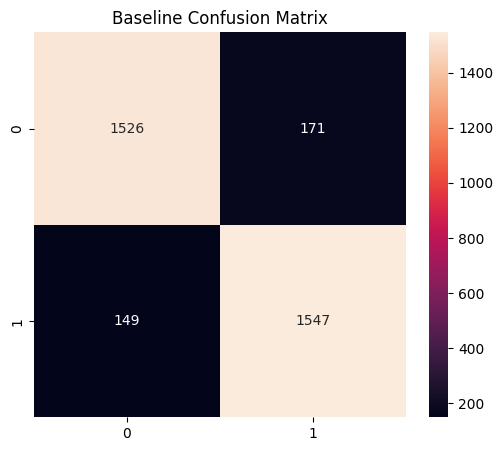

In [16]:

# Baseline XGBoost
scale_pos_weight = 1.0
if len(np.unique(y_train)) == 2:
    vals = np.unique(y_train, return_counts=True)[1]
    scale_pos_weight = float(vals.max()/vals.min()) if vals.min()>0 else 1.0

baseline = Pipeline([
    ('pre', preprocessor),
    ('clf', XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=RANDOM_STATE, n_jobs=-1))
])
baseline.fit(X_train, y_train)
y_pred = baseline.predict(X_test)

print('Baseline accuracy:', accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d')
plt.title('Baseline Confusion Matrix')
plt.show()


In [17]:

if OPTUNA_AVAILABLE:
    print('Running Optuna tuning (25 trials)...')
    def objective(trial: Trial):
        param = {
            'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
            'max_depth': trial.suggest_int('max_depth', 3, 12),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.4, log=True),
            'subsample': trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.4, 1.0),
            'gamma': trial.suggest_float('gamma', 0.0, 5.0),
            'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 5.0),
            'reg_lambda': trial.suggest_float('reg_lambda', 0.0, 5.0),
            'scale_pos_weight': scale_pos_weight
        }
        clf = Pipeline([('pre', preprocessor), ('clf', XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=RANDOM_STATE, n_jobs=-1, **param))])
        scores = cross_val_score(clf, X_train, y_train, cv=3, scoring='accuracy', n_jobs=-1)
        return scores.mean()
    study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
    study.optimize(objective, n_trials=25, show_progress_bar=True)
    print('Best params:', study.best_trial.params)
    best_params = study.best_trial.params
    best_clf = Pipeline([('pre', preprocessor), ('clf', XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=RANDOM_STATE, n_jobs=-1, **best_params))])
    best_clf.fit(X_train, y_train)
else:
    print('Optuna not available — using RandomizedSearchCV (60 iterations)')
    from scipy.stats import randint, uniform
    param_dist = {
        'clf__n_estimators': randint(100, 1000),
        'clf__max_depth': randint(3, 12),
        'clf__learning_rate': uniform(0.01, 0.39),
        'clf__subsample': uniform(0.6, 0.4),
        'clf__colsample_bytree': uniform(0.4, 0.6),
        'clf__gamma': uniform(0, 5),
        'clf__reg_alpha': uniform(0, 5),
        'clf__reg_lambda': uniform(0, 5),
    }
    from sklearn.model_selection import StratifiedKFold
    cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=RANDOM_STATE)
    search = RandomizedSearchCV(Pipeline([('pre', preprocessor), ('clf', XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=RANDOM_STATE, n_jobs=-1))]),
                                param_distributions=param_dist, n_iter=60, scoring='accuracy', cv=cv, n_jobs=-1, verbose=2, random_state=RANDOM_STATE)
    search.fit(X_train, y_train)
    print('Best params (RandomizedSearchCV):', search.best_params_)
    best_clf = search.best_estimator_


Optuna not available — using RandomizedSearchCV (60 iterations)
Fitting 4 folds for each of 60 candidates, totalling 240 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [05:06:15] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best params (RandomizedSearchCV): {'clf__colsample_bytree': np.float64(0.8867225060416017), 'clf__gamma': np.float64(4.103197378719777), 'clf__learning_rate': np.float64(0.2541164713396134), 'clf__max_depth': 3, 'clf__n_estimators': 516, 'clf__reg_alpha': np.float64(3.2574238592889397), 'clf__reg_lambda': np.float64(1.033421799383727), 'clf__subsample': np.float64(0.7095844509284535)}


Tuned model accuracy: 0.9083407014441497
              precision    recall  f1-score   support

           0       0.92      0.89      0.91      1697
           1       0.89      0.93      0.91      1696

    accuracy                           0.91      3393
   macro avg       0.91      0.91      0.91      3393
weighted avg       0.91      0.91      0.91      3393



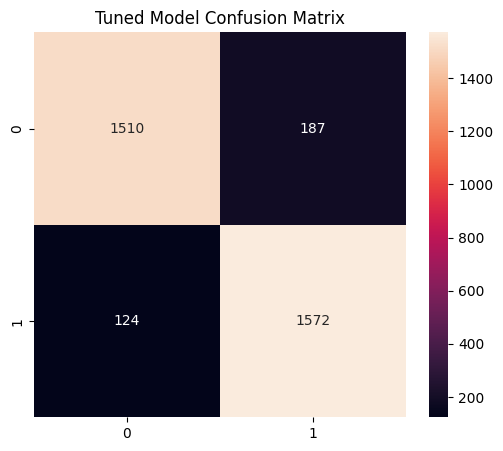

Saved trained model and predictions in /content/xgb_viva_output


In [18]:

y_pred_best = best_clf.predict(X_test)
print('Tuned model accuracy:', accuracy_score(y_test, y_pred_best))
print(classification_report(y_test, y_pred_best))

cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d')
plt.title('Tuned Model Confusion Matrix')
plt.show()

# Save model and predictions
import os
os.makedirs(OUTPUT_DIR, exist_ok=True)
joblib.dump(best_clf, os.path.join(OUTPUT_DIR, 'xgb_tuned_model.joblib'))
pd.DataFrame({'y_true': y_test, 'y_pred': y_pred_best}).to_csv(os.path.join(OUTPUT_DIR, 'predictions.csv'), index=False)
print('Saved trained model and predictions in', OUTPUT_DIR)


,feature,importance
5,hba1c_level,0.259650
1,age,0.230328
6,blood_glucose_level,0.185210
8,age_group,0.122777
2,hypertension,0.048554
4,bmi,0.038852
3,heart_disease,0.036339
7,bmi_category,0.028919
13,smoking_history_no_info,0.019140
10,gender_female,0.011353


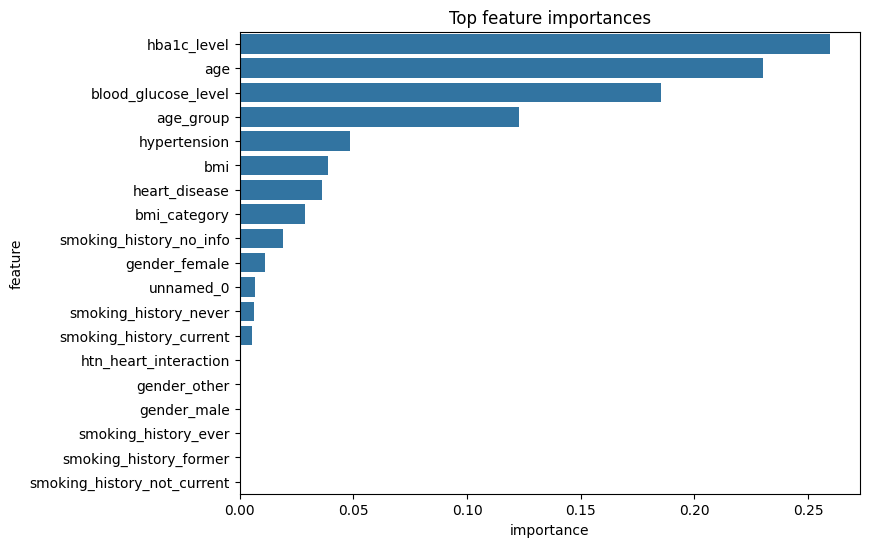

In [19]:

try:
    pre = best_clf.named_steps['pre']
    clf = best_clf.named_steps['clf']
    feature_names = []
    if 'num' in pre.named_transformers_:
        feature_names.extend(numeric_cols)
    if 'cat' in pre.named_transformers_ and categorical_cols:
        ohe = pre.named_transformers_['cat'].named_steps['onehot']
        ohe_names = ohe.get_feature_names_out(categorical_cols)
        feature_names.extend(list(ohe_names))
    importances = clf.feature_importances_
    fi = pd.DataFrame({'feature': feature_names[:len(importances)], 'importance': importances[:len(feature_names)]}).sort_values('importance', ascending=False).head(30)
    display(fi)
    plt.figure(figsize=(8,6))
    sns.barplot(x='importance', y='feature', data=fi)
    plt.title('Top feature importances')
    plt.show()
except Exception as e:
    print('Could not compute feature importances:', e)
